# Music Scratch/Click Auto-Restoration + Quality Enhancement (Free, Notebook-First)

This notebook implements a **fully automatic** pipeline for a music track that has **scratches/clicks** during playback and optionally applies **AI super-resolution** for perceptual quality improvement.

✅ Goals  
1. Auto-detect scratch/click events (impulse-like damage)  
2. Restore only the damaged parts (local inpainting)  
3. Optionally run **AudioSR** (open-source) for perceptual “quality uplift”  
4. Export clean audio and plots for verification

---

## What you need
- A Python environment (venv/conda) with scientific audio libs
- Your input audio file (`.wav` preferred; `.mp3` OK)
- Optional: NVIDIA GPU for AudioSR (CPU may be very slow for AI super-res)

> Tip (Cursor users): Open this notebook in Cursor, run cells top-to-bottom, and commit your results.


## 0) Config: Paths & Output Folder

Put your input file path below.  
Outputs will be saved into `./outputs/`.


In [15]:
import os
from pathlib import Path

# ==== USER EDIT ====
INPUT_AUDIO = "asserts/tuki_input.wav"   # e.g., "tuki_output_2.wav" or "input.mp3"
PROJECT_DIR = Path(".")
OUT_DIR = PROJECT_DIR / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Input:", INPUT_AUDIO)
print("Output dir:", OUT_DIR.resolve())


Input: asserts/tuki_input.wav
Output dir: /home/kagamirudo/CS-614_Application_ML_AI/Applications/outputs


## 1) Install dependencies (free)

This pipeline uses:
- numpy / scipy (signal processing)
- soundfile (I/O for WAV/FLAC)
- librosa (audio utilities)
- matplotlib (plots)

If you’re using MP3, install `ffmpeg` on your system:
- Ubuntu: `sudo apt-get update && sudo apt-get install -y ffmpeg`
- Windows: install FFmpeg and ensure it’s on PATH


In [16]:
# If you're in a fresh environment, uncomment:
# %pip install -U numpy scipy soundfile librosa matplotlib

import numpy as np
import scipy.signal as sps
import soundfile as sf
import librosa
import matplotlib.pyplot as plt

print("OK: imports loaded")


OK: imports loaded


## 2) Load audio (keep original sample rate)

We load the file as stereo if available.
If MP3 fails in `soundfile`, we fall back to `librosa.load` (mono + duplicated channels).


In [17]:
def load_audio(path: str):
    path = str(path)
    try:
        y, sr = sf.read(path, always_2d=True)
        y = y.astype(np.float32)
        return y, sr
    except Exception as e:
        print("soundfile read failed, falling back to librosa:", e)
        y_mono, sr = librosa.load(path, sr=None, mono=True)
        y = np.stack([y_mono, y_mono], axis=1).astype(np.float32)
        return y, sr

y, sr = load_audio(INPUT_AUDIO)
dur = y.shape[0] / sr
print(f"Loaded: shape={y.shape}  sr={sr}  duration={dur/60:.2f} min")


Loaded: shape=(8574636, 2)  sr=44100  duration=3.24 min


## 3) Quick visual check: waveform + spectrogram

Scratches/clicks usually appear as **vertical broadband lines** in the spectrogram.


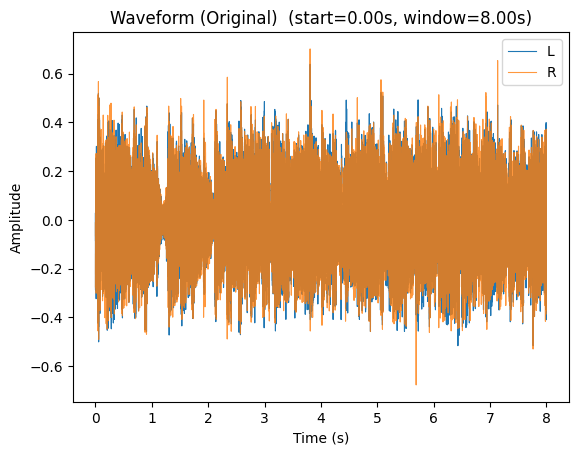

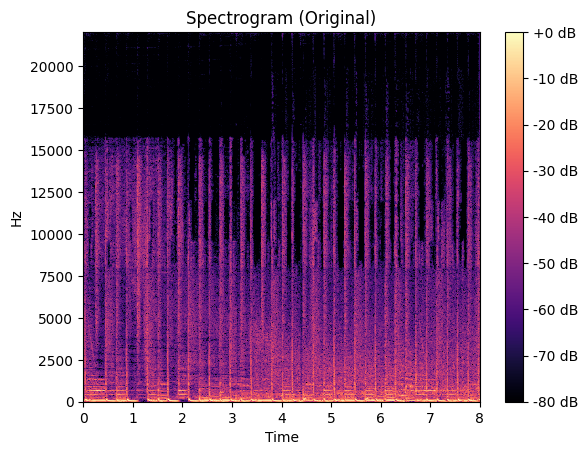

In [18]:
import librosa.display

def plot_wave_and_spec(y, sr, seconds=8.0, start_sec=0.0, title=""):
    n0 = int(start_sec * sr)
    n1 = int(min(len(y), (start_sec + seconds) * sr))
    seg = y[n0:n1, :]
    t = np.arange(seg.shape[0]) / sr

    plt.figure()
    plt.title(f"Waveform {title}  (start={start_sec:.2f}s, window={seconds:.2f}s)")
    plt.plot(t, seg[:,0], label="L", linewidth=0.8)
    if seg.shape[1] > 1:
        plt.plot(t, seg[:,1], label="R", linewidth=0.8, alpha=0.8)
    plt.xlabel("Time (s)"); plt.ylabel("Amplitude")
    plt.legend(loc="upper right")
    plt.show()

    x = seg.mean(axis=1)
    n_fft = 2048
    hop = 256
    S = np.abs(librosa.stft(x, n_fft=n_fft, hop_length=hop, window="hann"))
    Sdb = librosa.amplitude_to_db(S, ref=np.max)

    plt.figure()
    plt.title(f"Spectrogram {title}")
    librosa.display.specshow(Sdb, sr=sr, hop_length=hop, x_axis="time", y_axis="hz")
    plt.colorbar(format="%+2.0f dB")
    plt.ylim(0, sr/2)
    plt.show()

plot_wave_and_spec(y, sr, seconds=8, start_sec=0, title="(Original)")


## 4) Scratch/Click detection (automatic)

We detect impulsive damage using:
1) High-pass filter (focus on click energy)
2) Derivative envelope
3) Robust thresholding (MAD)
4) Group hits into events and expand into short repair windows

Output: list of windows `(start_sample, end_sample)` to repair.


In [19]:
def highpass(x, sr, cutoff_hz=4000.0, order=4):
    sos = sps.butter(order, cutoff_hz/(sr/2), btype="highpass", output="sos")
    return sps.sosfiltfilt(sos, x)

def mad_threshold(v, k=12.0):
    med = np.median(v)
    mad = np.median(np.abs(v - med)) + 1e-12
    return med + k * 1.4826 * mad

def detect_clicks(y, sr, hp_cut=4000.0, k=12.0,
                  min_gap_ms=3.0, pre_ms=2.0, post_ms=6.0):
    x = y.mean(axis=1)
    x_hp = highpass(x, sr, cutoff_hz=hp_cut)
    dx = np.diff(x_hp, prepend=x_hp[0])
    env = np.abs(dx)

    thr = mad_threshold(env, k=k)
    hits = np.where(env > thr)[0]
    if len(hits) == 0:
        return [], thr

    min_gap = int((min_gap_ms/1000.0) * sr)
    groups = []
    start = hits[0]
    prev = hits[0]
    for h in hits[1:]:
        if h - prev <= min_gap:
            prev = h
        else:
            groups.append((start, prev))
            start = h
            prev = h
    groups.append((start, prev))

    pre = int((pre_ms/1000.0) * sr)
    post = int((post_ms/1000.0) * sr)

    windows = []
    for a, b in groups:
        s0 = max(0, a - pre)
        s1 = min(len(x), b + post)
        if s1 > s0:
            windows.append((s0, s1))
    return windows, thr

windows, thr = detect_clicks(y, sr)
print(f"Detected {len(windows)} click/scratch windows. Threshold={thr:.6g}")
print("First 10 windows (samples):", windows[:10])


Detected 1725 click/scratch windows. Threshold=0.0986976
First 10 windows (samples): [(np.int64(1597), np.int64(1980)), (np.int64(10942), np.int64(12646)), (np.int64(19621), np.int64(20326)), (np.int64(20150), np.int64(20510)), (np.int64(21119), np.int64(21573)), (np.int64(29403), np.int64(30150)), (np.int64(30116), np.int64(30468)), (np.int64(30890), np.int64(31242)), (np.int64(38237), np.int64(38654)), (np.int64(38657), np.int64(39077))]


### 4.1) Visualize detected events on the waveform

Adjust `start_sec` / `seconds` until you see the scratch regions highlighted.


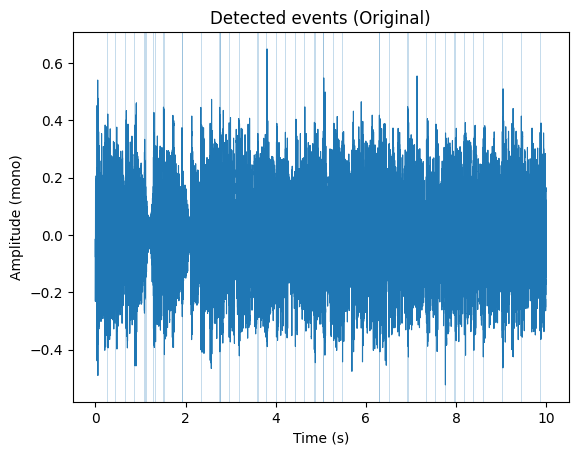

In [20]:
def plot_events_on_wave(y, sr, windows, start_sec=0.0, seconds=10.0, title=""):
    n0 = int(start_sec * sr)
    n1 = int(min(len(y), (start_sec + seconds) * sr))
    seg = y[n0:n1, :].mean(axis=1)
    t = np.arange(seg.shape[0]) / sr + start_sec

    plt.figure()
    plt.title(f"Detected events {title}")
    plt.plot(t, seg, linewidth=0.8)
    for (a, b) in windows:
        if b < n0 or a > n1:
            continue
        aa = max(a, n0); bb = min(b, n1)
        plt.axvspan(aa/sr, bb/sr, alpha=0.25)
    plt.xlabel("Time (s)"); plt.ylabel("Amplitude (mono)")
    plt.show()

plot_events_on_wave(y, sr, windows, start_sec=0, seconds=10, title="(Original)")


## 5) Restore damaged regions (local inpainting)

We **do not** denoise the whole track.
We repair only the detected windows.

Method: **LPC / AR interpolation**
- Fit an AR model on clean context around each click
- Synthesize a replacement segment
- Crossfade boundaries to avoid seams


In [21]:
from scipy.linalg import toeplitz

def lpc_ar_coeffs(x, order):
    r = np.correlate(x, x, mode="full")
    mid = len(r)//2
    r = r[mid:mid+order+1]
    R = toeplitz(r[:-1])
    rhs = -r[1:]
    a = np.linalg.solve(R + 1e-8*np.eye(order), rhs)
    return a

def ar_predict_forward(seed, a, n):
    order = len(a)
    y = []
    buf = list(seed[-order:])
    for _ in range(n):
        pred = -sum(a[k] * buf[-k-1] for k in range(order))
        y.append(pred)
        buf.append(pred)
    return np.array(y, dtype=np.float32)

def repair_window_lpc(x, s0, s1, sr, order=32, ctx_ms=25.0, xfade_ms=3.0):
    n = len(x)
    ctx = int((ctx_ms/1000.0)*sr)
    xfade = int((xfade_ms/1000.0)*sr)

    pre0 = max(0, s0 - ctx)
    pre1 = s0
    post0 = s1
    post1 = min(n, s1 + ctx)

    pre = x[pre0:pre1]
    post = x[post0:post1]
    gap = s1 - s0

    if len(pre) < order+2 or len(post) < order+2 or gap <= 0:
        return x

    ctx_sig = np.concatenate([pre, post])
    ctx_sig = ctx_sig - np.mean(ctx_sig)
    a = lpc_ar_coeffs(ctx_sig, order=order)

    seed = pre[-order:]
    fill_fwd = ar_predict_forward(seed, a, gap)

    post_rev = post[::-1]
    seed_rev = post_rev[-order:]
    fill_bwd_rev = ar_predict_forward(seed_rev, a, gap)
    fill_bwd = fill_bwd_rev[::-1]

    w = np.linspace(0, 1, gap, dtype=np.float32)
    fill = (1-w)*fill_fwd + w*fill_bwd

    out = x.copy()
    out[s0:s1] = fill

    if xfade > 0:
        a0 = max(0, s0 - xfade)
        b0 = s0
        if b0 > a0:
            m = b0 - a0
            win = np.linspace(0, 1, m, dtype=np.float32)
            out[a0:b0] = (1-win)*x[a0:b0] + win*out[a0:b0]

        a1 = s1
        b1 = min(n, s1 + xfade)
        if b1 > a1:
            m = b1 - a1
            win = np.linspace(0, 1, m, dtype=np.float32)
            out[a1:b1] = (1-win)*out[a1:b1] + win*x[a1:b1]

    return out

def repair_clicks_stereo(y, sr, windows, **kwargs):
    y_out = y.copy()
    for ch in range(y.shape[1]):
        x = y[:, ch].astype(np.float32)
        for (s0, s1) in windows:
            x = repair_window_lpc(x, s0, s1, sr, **kwargs)
        y_out[:, ch] = x
    return y_out

y_repaired = repair_clicks_stereo(
    y, sr, windows,
    order=32,
    ctx_ms=25.0,
    xfade_ms=3.0
)

REPAIRED_WAV = OUT_DIR / "repaired_clicks.wav"
sf.write(REPAIRED_WAV, y_repaired, sr)
print("Saved:", REPAIRED_WAV)


Saved: outputs/repaired_clicks.wav


### 5.1) Before/after comparison on a region

Change `start_sec` to a region where scratches are audible.


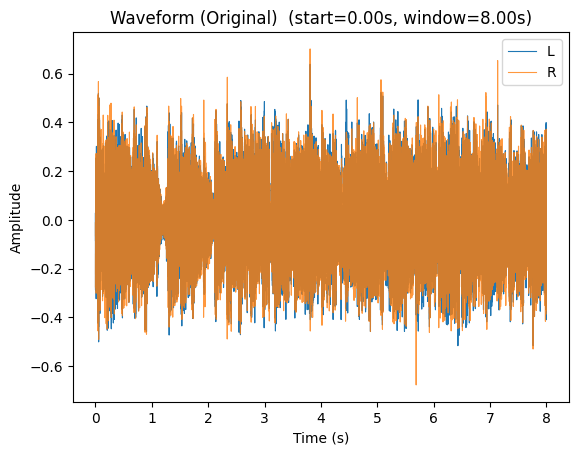

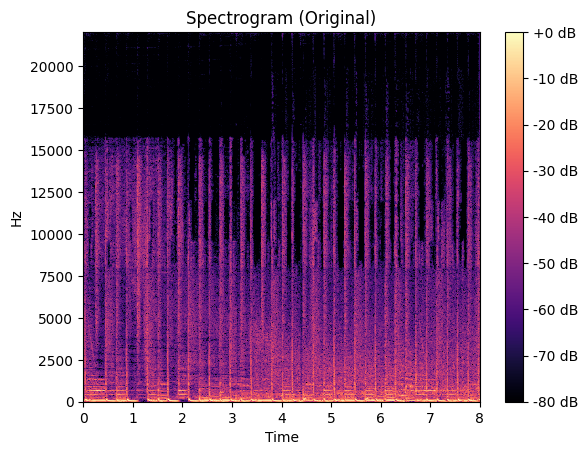

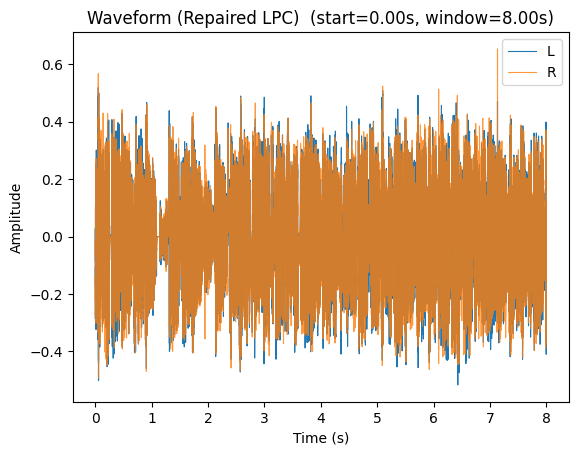

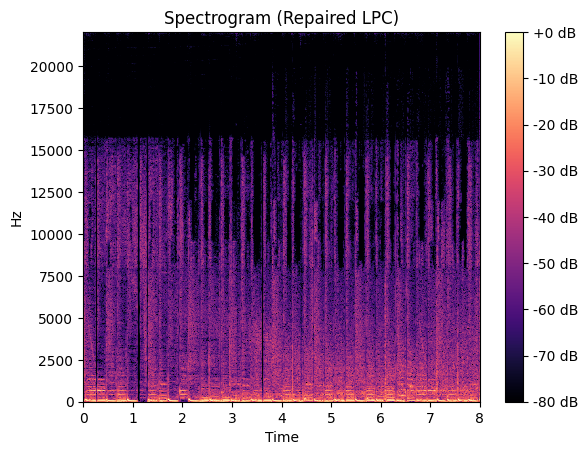

In [22]:
start_sec = 0.0
plot_wave_and_spec(y, sr, seconds=8, start_sec=start_sec, title="(Original)")
plot_wave_and_spec(y_repaired, sr, seconds=8, start_sec=start_sec, title="(Repaired LPC)")


## 6) Optional gentle de-crackle (only if needed)

If your file has dense micro-crackle, you can apply a *very gentle* median filter
only on a high-passed component and subtract a small portion of the residual.

This can dull transients if overused, so keep `mix` small.


In [23]:
def gentle_decrackle(y, sr, hp_cut=6000.0, med_len=5, mix=0.25):
    y_out = y.copy()
    for ch in range(y.shape[1]):
        x = y[:, ch]
        x_hp = highpass(x, sr, cutoff_hz=hp_cut)
        x_hp_med = sps.medfilt(x_hp, kernel_size=med_len)
        resid = x_hp - x_hp_med
        y_out[:, ch] = x - mix * resid
    return y_out

# Uncomment to try:
# y_repaired2 = gentle_decrackle(y_repaired, sr, hp_cut=6000, med_len=5, mix=0.25)
# sf.write(OUT_DIR / "repaired_clicks_decrackle.wav", y_repaired2, sr)
# plot_wave_and_spec(y_repaired2, sr, seconds=8, start_sec=start_sec, title="(Repaired + gentle decrackle)")


## 7) Optional AI “quality uplift”: AudioSR (open-source)

AudioSR performs audio super-resolution / bandwidth extension.

Because repositories evolve, this section provides **annotated template cells**
to clone/install/run after you read the repo README.

Recommended repo:
- https://github.com/haoheliu/versatile_audio_super_resolution


In [29]:
# Optional: check GPU / ffmpeg availability
import shutil, subprocess

print("ffmpeg available:", shutil.which("ffmpeg") is not None)
# !nvidia-smi  # uncomment if you have NVIDIA GPU


ffmpeg available: True


In [30]:
# ==== OPTIONAL: Clone AudioSR ====
from pathlib import Path

AUDIOSR_DIR = OUT_DIR / "audiosr_repo"
REPO_URL = "https://github.com/haoheliu/versatile_audio_super_resolution.git"

print("AudioSR repo dir:", AUDIOSR_DIR)
print("Repo URL:", REPO_URL)

# Uncomment to run:
# !git clone {REPO_URL} {AUDIOSR_DIR}


AudioSR repo dir: outputs/audiosr_repo
Repo URL: https://github.com/haoheliu/versatile_audio_super_resolution.git


In [31]:
# ==== OPTIONAL: Install AudioSR requirements ====
# After cloning, check for a requirements.txt or environment.yml

# Example (EDIT as needed):
# %pip install -r {AUDIOSR_DIR/'requirements.txt'}

print("Edit this cell to match the repo's install instructions.")


Edit this cell to match the repo's install instructions.


In [1]:
# Install AudioSR once in this environment (commented to avoid re-running every time)
# On a machine with NVIDIA CUDA, this will install CUDA builds.
# On this AMD/ROCm box it will usually run on CPU.
%pip install -U audiosr

Note: you may need to restart the kernel to use updated packages.


In [1]:
from audiosr import build_model, super_resolution, save_wave

from pathlib import Path  # Ensure Path is imported
# Use the repaired-clicks WAV as AudioSR input
AI_IN = str("asserts/tuki_input.wav")
AI_OUT_DIR = Path("outputs/audiosr")
AI_OUT_DIR.mkdir(parents=True, exist_ok=True)

print("AudioSR input:", AI_IN)
print("AudioSR output dir:", AI_OUT_DIR)

# Build model (device="auto" → CUDA if available, else CPU)
model = build_model(model_name="basic", device="auto")

# Run super-resolution (single file)
waveform = super_resolution(
    model,
    AI_IN,
    seed=42,
    ddim_steps=50,
    guidance_scale=3.5,
    latent_t_per_second=12.8,
)

# Save (48000 Hz)
save_wave(
    waveform,
    inputpath=AI_IN,
    savepath=str(AI_OUT_DIR),
    name="repaired_clicks_audiosr",
    samplerate=48000,
)

print("AudioSR finished. Check:", AI_OUT_DIR)

/opt/audiofix-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/audiofix-env/lib/python3.11/site-packages/librosa/util/files.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
/opt/audiofix-env/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/opt/audiofix-env/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: FutureWarning: 

AudioSR input: asserts/tuki_input.wav
AudioSR output dir: outputs/audiosr
Loading AudioSR: basic
Loading model on cpu


/opt/audiofix-env/lib/python3.11/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/opt/audiofix-env/lib/python3.11/site-packages/torchaudio/transforms/_transforms.py:580: UserWarning: Argument 'onesided' has been deprecated and has no influence on the behavior of this module.
  warnings.warn(


DiffusionWrapper has 258.20 M params.


/opt/audiofix-env/lib/python3.11/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/opt/audiofix-env/lib/python3.11/site-packages/audiosr/pipeline.py:143: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start set

: 

In [27]:
# ==== OPTIONAL: Run AudioSR inference (TEMPLATE) ====
AI_IN  = str(REPAIRED_WAV)
AI_OUT = str(OUT_DIR / "repaired_clicks_AudioSR.wav")

print("AudioSR input:", AI_IN)
print("AudioSR output:", AI_OUT)

# Template (EDIT after reading repo):
# !python {AUDIOSR_DIR/'inference.py'} --input "{AI_IN}" --output "{AI_OUT}" --sr 44100

print("Edit the command to match the repo's inference script/CLI.")


AudioSR input: outputs/repaired_clicks.wav
AudioSR output: outputs/repaired_clicks_AudioSR.wav
Edit the command to match the repo's inference script/CLI.
The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


## 8) Export deliverables (WAV + high-bitrate MP3/AAC)

After restoration (and optional AI enhancement), export:
- WAV (best archival)
- MP3 320k or AAC 256k (distribution)

If you ran AudioSR, set `FINAL_WAV` to the AI output.


In [28]:
import shutil, subprocess

FINAL_WAV = REPAIRED_WAV  # change to AI output if you ran AudioSR
FINAL_MP3 = OUT_DIR / "final_320k.mp3"
FINAL_AAC = OUT_DIR / "final_256k.m4a"

if shutil.which("ffmpeg"):
    subprocess.run(["ffmpeg","-y","-i",str(FINAL_WAV),"-b:a","320k",str(FINAL_MP3)],
                   check=False, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    subprocess.run(["ffmpeg","-y","-i",str(FINAL_WAV),"-c:a","aac","-b:a","256k",str(FINAL_AAC)],
                   check=False, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    print("Exported:", FINAL_MP3)
    print("Exported:", FINAL_AAC)
else:
    print("ffmpeg not found. Install ffmpeg to export MP3/AAC.")


Exported: outputs/final_320k.mp3
Exported: outputs/final_256k.m4a


## 9) Tuning guide

If the detector misses scratches:
- lower `k` from 12 → 10 → 8
- increase `hp_cut` from 4k → 6k

If you detect too many false positives:
- raise `k` (12 → 14 → 16)
- increase `min_gap_ms` to merge micro-events
- reduce `post_ms` / `pre_ms`

If repair sounds unnatural:
- reduce AR order (32 → 24)
- increase `ctx_ms` (25 → 40)
- decrease window expansion (`pre_ms`/`post_ms`)
